In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [3]:
news_df = pd.read_csv("data/processed_news_data.csv")  # Dataset with keyword counts
crimes_df = pd.read_csv("data/crimes_number.csv")  # Dataset with crime counts

# Convert dates to datetime format
news_df["Дата"] = pd.to_datetime(news_df["Дата"])
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], format="%Y-%m")

# Convert dates to 'YYYY-MM' format
news_df["Дата"] = news_df["Дата"].dt.to_period("M")
crimes_df["Date"] = crimes_df["Date"].dt.to_period("M")

# Merge datasets by the date column
df = pd.merge(news_df, crimes_df, left_on="Дата", right_on="Date", how="inner")

# Remove duplicate date column if necessary
df.drop(columns=["Дата"], inplace=True)

In [4]:
# Translate keywords to english
column_translation = {
    "коррупция": "corruption",
    "взятка": "bribe",
    "приговор": "verdict",
    "хищение": "embezzlement",
    "расследование": "investigation",
    "задержание": "detention",
    "доллар": "dollar",
    "миллион": "million",
    "миллиард": "billion",
    "агентство": "agency",
    "преступление": "crime",
    "суд": "court",
    "министерство": "ministry",
    "аким": "akim",
    "начальник": "chief",
    "заместитель": "deputy",
    "район": "district",
    "город": "city",
    "область": "region",
    "правонарушение": "offense",
}

df.rename(columns=column_translation, inplace=True)


In [5]:
df.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,...,ministry,akim,chief,deputy,district,city,region,offense,Date,Total Crimes
0,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,...,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,2016-11,3463.0
1,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,...,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,2016-12,3214.0
2,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,...,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,2017-01,1137.0
3,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,...,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,2017-02,1337.0
4,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,...,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,2017-03,1566.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   corruption     99 non-null     int64    
 1   bribe          99 non-null     float64  
 2   verdict        99 non-null     float64  
 3   embezzlement   99 non-null     float64  
 4   investigation  99 non-null     float64  
 5   detention      99 non-null     float64  
 6   dollar         99 non-null     float64  
 7   million        99 non-null     float64  
 8   billion        99 non-null     float64  
 9   agency         99 non-null     float64  
 10  crime          99 non-null     float64  
 11  court          99 non-null     float64  
 12  ministry       99 non-null     float64  
 13  akim           99 non-null     float64  
 14  chief          99 non-null     float64  
 15  deputy         99 non-null     float64  
 16  district       99 non-null     float64  
 17  city           99 

In [7]:
df['Date'] = df['Date'].dt.to_timestamp('s').dt.strftime('%Y-%m-%d')
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,...,ministry,akim,chief,deputy,district,city,region,offense,Date,Total Crimes
0,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,...,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0,2016-11-01,3463.0
1,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,...,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0,2016-12-01,3214.0
2,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,...,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,2017-01-01,1137.0
3,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,...,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0,2017-02-01,1337.0
4,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,...,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0,2017-03-01,1566.0


Correlation with the target variable:
Total Crimes     1.000000
dollar           0.265334
corruption       0.194084
crime            0.191749
bribe            0.174378
investigation    0.172849
agency           0.151473
ministry         0.148085
region           0.132093
detention        0.123826
district         0.121275
city             0.108854
million          0.108031
akim             0.101624
deputy           0.094644
verdict          0.077149
chief            0.045715
court            0.032344
offense          0.031368
embezzlement     0.013643
billion         -0.084033
Date            -0.413425
Name: Total Crimes, dtype: float64


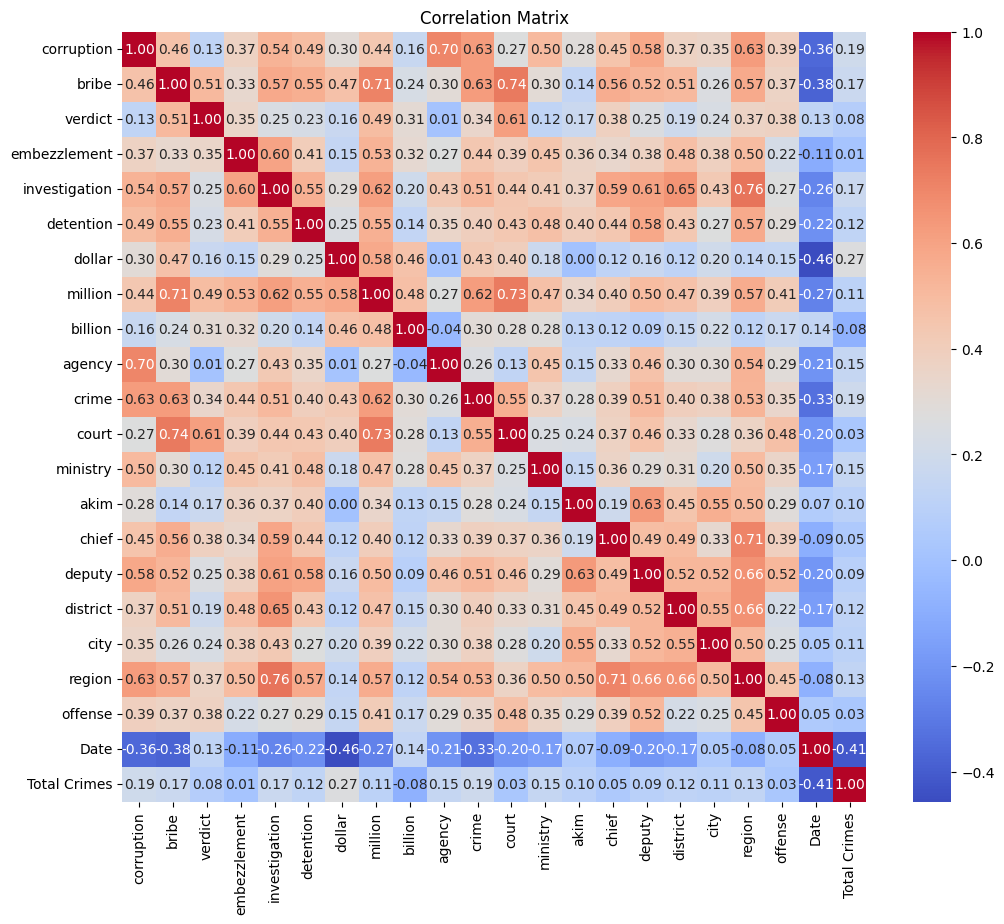

In [9]:
# Calculate correlation
correlation_matrix = df.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [10]:
# Create a new dataframe with aggregated features
df_agg = pd.DataFrame()

# Aggregated features
df_agg['Corruption_Sum'] = df[['corruption', 'bribe', 'verdict', 'embezzlement', 'investigation']].sum(axis=1)
df_agg['Detentions_Sum'] = df[['detention']].sum(axis=1)
df_agg['Finance_Sum'] = df[['dollar', 'million', 'billion']].sum(axis=1)
df_agg['Authorities_Sum'] = df[['agency', 'ministry', 'akim', 'chief', 'deputy', 'district', 'city', 'region']].sum(axis=1)
df_agg['Offenses_Sum'] = df[['crime', 'offense', 'court']].sum(axis=1)

# Add time components
# df_agg['Month'] = pd.to_datetime(df['Date']).dt.month
# df_agg['Year'] = pd.to_datetime(df['Date']).dt.year

# Target variable
df_agg['Total Crimes'] = df['Total Crimes']

df_agg


,Corruption_Sum,Detentions_Sum,Finance_Sum,Authorities_Sum,Offenses_Sum,Total Crimes
0,161.0,20.0,57.0,125.0,56.0,3463.0
1,81.0,7.0,19.0,76.0,28.0,3214.0
2,86.0,16.0,24.0,75.0,32.0,1137.0
3,90.0,10.0,69.0,50.0,56.0,1337.0
4,119.0,8.0,65.0,117.0,99.0,1566.0
...,...,...,...,...,...,...
94,64.0,13.0,35.0,98.0,42.0,1903.0
95,61.0,1.0,61.0,79.0,22.0,1989.0
96,77.0,5.0,36.0,73.0,52.0,2100.0
97,64.0,7.0,39.0,62.0,40.0,2098.0


Correlation with the target variable:
Total Crimes       1.000000
Corruption_Sum     0.200789
Authorities_Sum    0.161576
Detentions_Sum     0.123826
Finance_Sum        0.120446
Offenses_Sum       0.075755
Name: Total Crimes, dtype: float64


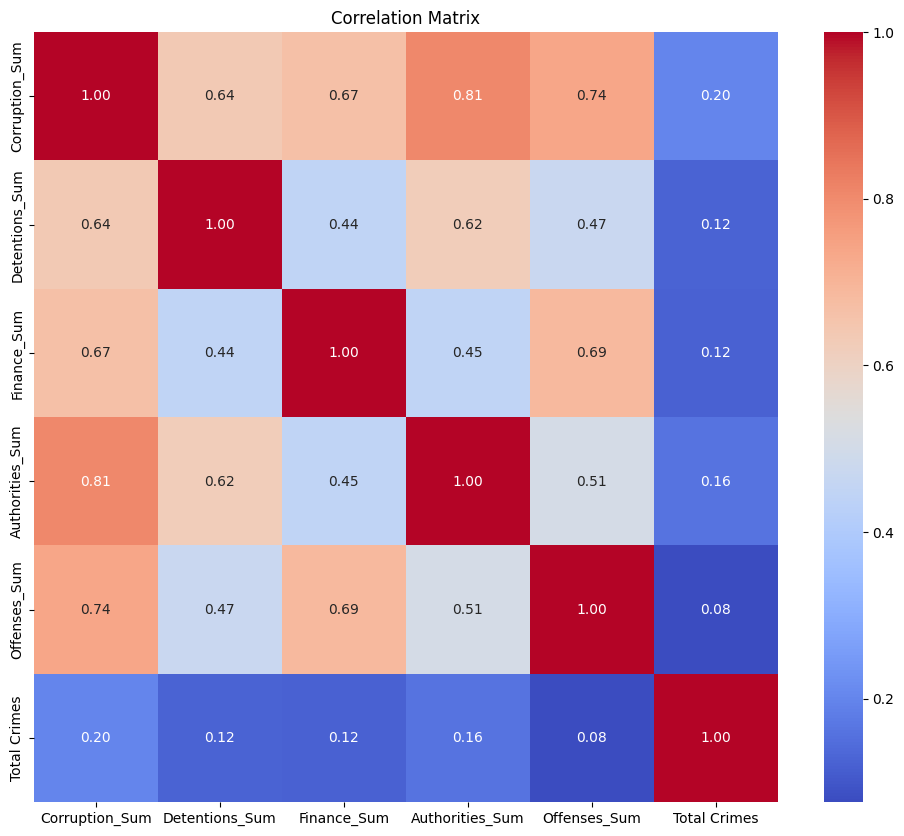

In [11]:
# Calculate correlation
correlation_matrix = df_agg.corr()

# Display correlation of the target variable with other features
target_corr = correlation_matrix["Total Crimes"].sort_values(ascending=False)
print("Correlation with the target variable:")
print(target_corr)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [12]:
# df_agg_new = df_agg[['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum', 'Offenses_Sum']].sum(axis=1)
# df_agg_new = df_agg_new.to_frame(name="Total_Keywords")  # Преобразуем в DataFrame с названием столбца
# df_agg_new = pd.concat([df_agg[["Month", "Year", "Total Crimes"]], df_agg_new], axis=1)  # Объединяем


In [13]:
# plt.figure(figsize=(12, 6))

# # Строим график количества ключевых слов
# plt.plot(df_agg_new["Year"].astype(str) + "-" + df_agg_new["Month"].astype(str), 
#          df_agg_new["Total_Keywords"], 
#          label="Total Keywords", color="blue", marker="o")

# # Строим график количества преступлений
# plt.plot(df_agg_new["Year"].astype(str) + "-" + df_agg_new["Month"].astype(str), 
#          df_agg_new["Total Crimes"], 
#          label="Total Crimes", color="red", marker="o")

# # Улучшаем вид
# plt.xticks(rotation=45)  # Поворачиваем подписи на оси X
# plt.xlabel("Time (Year-Month)")
# plt.ylabel("Count")
# plt.title("Trends of Keywords and Corruption Crimes Over Time")
# plt.legend()
# plt.grid()

# plt.show()

In [14]:
# from scipy.stats import pearsonr

# # Рассчитываем коэффициент корреляции Пирсона
# corr, p_value = pearsonr(df_agg_new["Total_Keywords"], df_agg_new["Total Crimes"])

# print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.3f}")


In [15]:
# from statsmodels.tsa.stattools import grangercausalitytests

# # Подготовка данных (нужен временной лаг, например, 1 месяц)
# data = df_agg_new[["Total Crimes", "Total_Keywords"]].dropna()

# # Тест Гранджера с лагом 1
# test_result = grangercausalitytests(data, maxlag=1, verbose=True)


In [16]:
# Splitting the original dataset into features (X) and target variable (y)
X_df = df.drop(columns=["Total Crimes", "Date"])
y_df = df["Total Crimes"]
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.2, random_state=13)

# Splitting the aggregated dataset into features (X) and target variable (y)
X_agg = df_agg.drop(columns=["Total Crimes"])
y_agg = df_agg["Total Crimes"]
X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y_agg, test_size=0.2, random_state=13)

In [17]:
# Function for training and evaluating a model
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}")
    print("-" * 30)

In [18]:
# List of models
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=13)),
    ("Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=100, random_state=13)),
    ("XGBoost Regressor", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=13))
]

In [19]:
# Training and evaluation for df
print("Model evaluation on df:")
for name, model in models:
    evaluate_model(model, X_train_df, X_test_df, y_train_df, y_test_df, name)

# Training and evaluation for df_agg
print("Model evaluation on df_agg:")
for name, model in models:
    evaluate_model(model, X_train_agg, X_test_agg, y_train_agg, y_test_agg, name)

Model evaluation on df:
Linear Regression:
MAE: 554.20, MSE: 586670.13, R2: -0.47
------------------------------
Ridge Regression:
MAE: 553.98, MSE: 586135.83, R2: -0.47
------------------------------
Lasso Regression:
MAE: 554.17, MSE: 586606.47, R2: -0.47
------------------------------
ElasticNet:
MAE: 553.32, MSE: 584546.31, R2: -0.47
------------------------------
Random Forest Regressor:
MAE: 474.45, MSE: 379755.30, R2: 0.05
------------------------------
Gradient Boosting Regressor:
MAE: 541.85, MSE: 475861.61, R2: -0.19
------------------------------
XGBoost Regressor:
MAE: 530.06, MSE: 462366.49, R2: -0.16
------------------------------
Model evaluation on df_agg:
Linear Regression:
MAE: 506.82, MSE: 401893.16, R2: -0.01
------------------------------
Ridge Regression:
MAE: 506.82, MSE: 401888.87, R2: -0.01
------------------------------
Lasso Regression:
MAE: 506.82, MSE: 401883.35, R2: -0.01
------------------------------
ElasticNet:
MAE: 506.81, MSE: 401871.38, R2: -0.01
---

GradientBoostingRegressor это Boosted hybrids?

Да, именно. GradientBoostingRegressor является примером boosted hybrid метода, поскольку он итеративно обучается на остатках предыдущих моделей (деревьев). Каждый следующий этап фокусируется на ошибках предыдущего, что позволяет улучшать точность прогноза. Это соответствует принципу, описанному выше: модель сначала предсказывает одну компоненту (например, тренд), а затем корректирует ошибки, обучаясь на остатках.


Boosted hybrids (гибриды на основе подгонки остаточных ошибок):
Здесь используется модель, способная экстраполировать тренд (например, линейная регрессия), чтобы сначала предсказать и вычесть трендовую составляющую из исходного ряда. Остатки (то, что осталось после удаления тренда) затем моделируются с помощью модели, которая хорошо улавливает сложные нелинейные зависимости, например, XGBoost.
Таким образом, модель сначала «отделяет» тренд, а потом обучается на оставшихся ошибках, что напоминает принцип работы градиентного бустинга (где каждая последующая модель обучается на ошибках предыдущей).

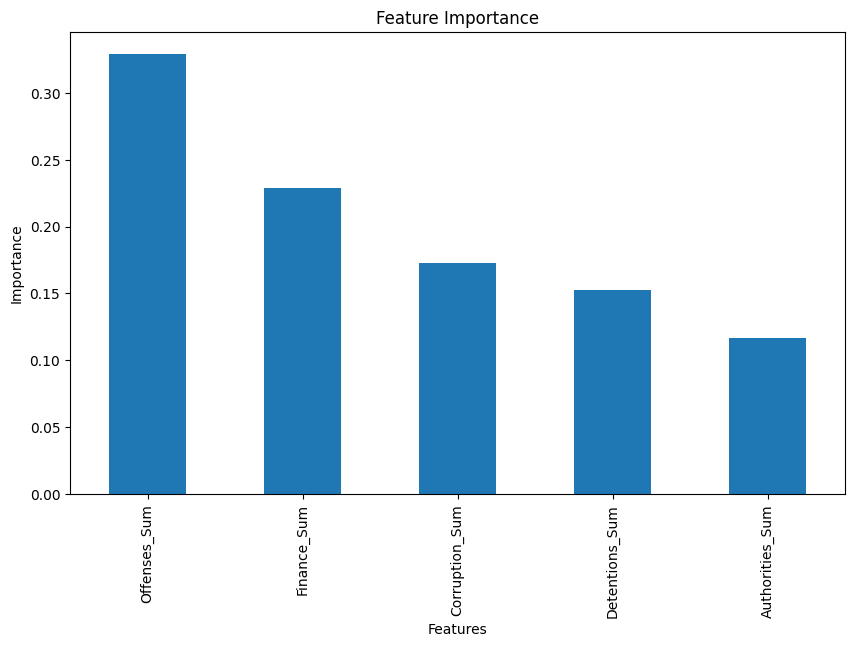

In [20]:
# Обучение модели XGBoost на агрегированных данных
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb_model.fit(X_train_agg, y_train_agg)

# Вычисление важности признаков
importance = pd.Series(xgb_model.feature_importances_, index=X_agg.columns)

# Сортировка и визуализация
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 6), title="Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Year and month are the highest correlation with total crimes number. Thus, we use Time Series Analysis

In [21]:
df_agg.columns

Index(['Corruption_Sum', 'Detentions_Sum', 'Finance_Sum', 'Authorities_Sum',
       'Offenses_Sum', 'Total Crimes'],
      dtype='object')

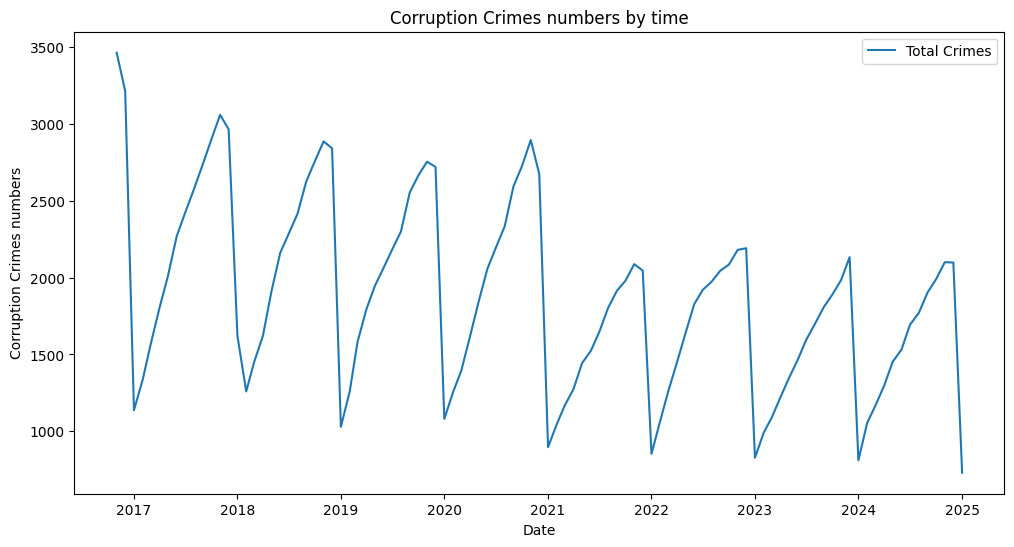

In [22]:
# Убедимся, что 'Дата' является индексом
# df_agg['Date'] = pd.to_datetime(df_agg['Year'].astype(str) + '-' + df_agg['Month'].astype(str))
df_agg['Date'] = df['Date']
df_agg.set_index('Date', inplace=True)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df_agg.index, df_agg['Total Crimes'], label="Total Crimes")
plt.title("Corruption Crimes numbers by time")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes numbers")
plt.legend()
plt.show()

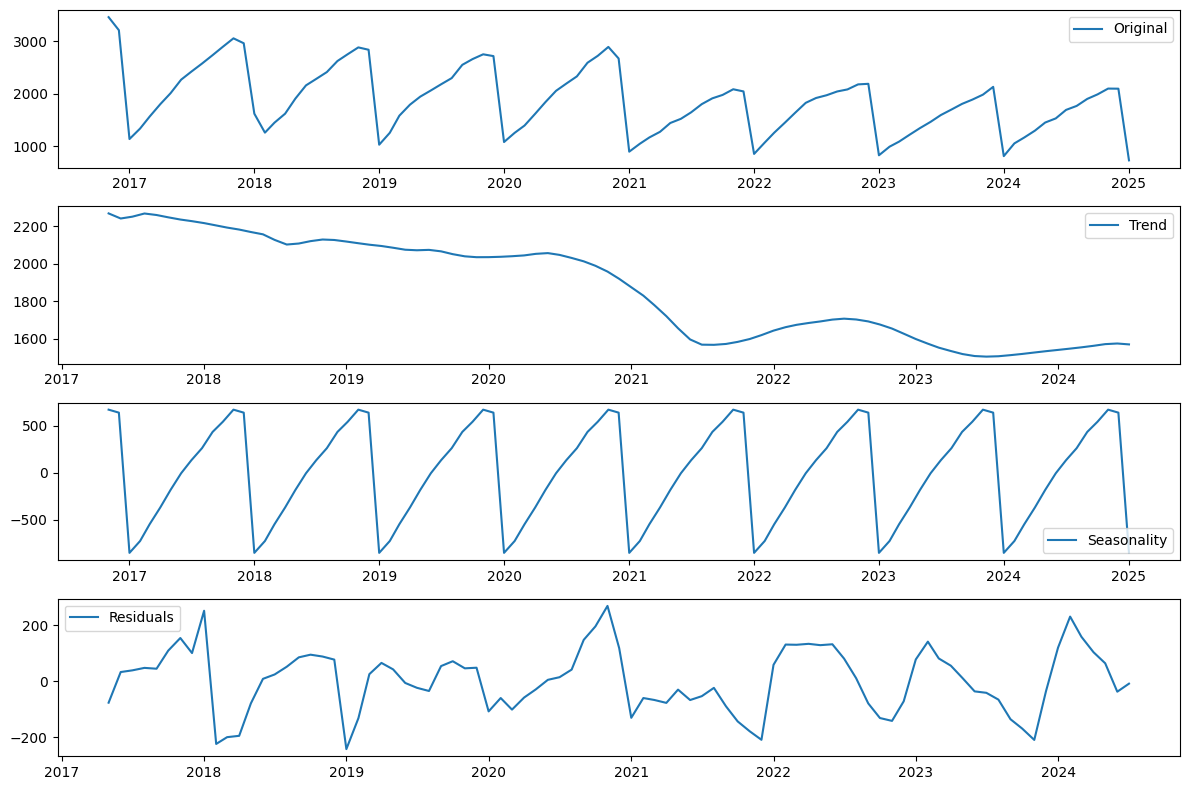

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition of the time series
decomposition = seasonal_decompose(df_agg['Total Crimes'], model='additive', period=12)

# Visualization of components
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_agg['Total Crimes'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


На графике видна декомпозиция временного ряда на четыре части:

Original (исходный ряд)

Показывает исходные данные: судя по графику, в конце каждого года наблюдаются пики, а в начале — низкие значения.

Trend (тренд)

Отражает долгосрочное направление. Здесь видно, что с 2017 по 2022 год тренд постепенно снижается, а затем с 2022 года начинает слегка расти.

Тренд показывает «средний уровень» без учёта регулярных колебаний.

Seasonality (сезонность)

Отображает повторяющиеся паттерны в течение года. Видно, что каждый год сезонная волна похожа: значения достигают максимума к концу года и минимума где-то ближе к началу.

Амплитуда сезонности (разница между пиками и впадинами) остаётся примерно одинаковой из года в год.

Residuals (остатки)

Это разница между исходным рядом и суммой (тренд + сезонность). Остатки колеблются вокруг нуля без явной структуры.

Если бы в остатках был выраженный тренд или повторяющиеся волны, это означало бы, что декомпозиция не учла какую-то закономерность. Здесь же, судя по всему, остатки выглядят достаточно случайными.

Что говорит такая картина
Наличие отчётливой сезонности: пик в конце года, спад в начале.

Долгосрочный спад с 2017 до ~2022 года, после чего идёт небольшой подъём.

Случайность остатков: модель декомпозиции хорошо «вытащила» основные закономерности (тренд и сезонность), а в остатках остались, в основном, непредсказуемые флуктуации.

Вывод
Такая декомпозиция подтверждает, что ряд действительно состоит из ярко выраженной сезонности, чётко прослеживаемого тренда и некоторого случайного шума. Это помогает при выборе и настройке моделей прогнозирования — например, вы можете отдельно учитывать сезонность (12 месяцев) и общий тренд, а также следить за поведением остатков, чтобы убедиться, что модель не пропускает важные паттерны.

Original (исходный временной ряд)

Наблюдается четко выраженная сезонность (ежегодные колебания).
В целом есть нисходящий тренд с 2017 по 2021, затем стабилизация.
Резкие падения в конце каждого года, возможно, связаны с отчетными периодами или административными циклами.
Trend (трендовая составляющая)

Видно, что общее число коррупционных преступлений снижалось примерно с 2018 по 2021 год, а затем вышло на плато.
Это может быть связано с изменением политики, законодательства или общественного внимания к коррупции.
После 2021 года ситуация стабилизировалась, но явного роста нет.
Seasonality (сезонность)

Очень стабильный годовой цикл: сначала резкий рост, затем спад.
Сезонность явно повторяется из года в год без значительных изменений.
Это говорит о том, что преступления, скорее всего, связаны с регулярными событиями (например, отчетными периодами, изменениями финансирования, антикоррупционными кампаниями).
Residuals (остатки)

Остатки не выглядят случайными, что говорит о наличии еще неучтенных факторов.
В идеале, если модель адекватно описывает данные, остатки должны быть случайным шумом без видимой структуры.
Здесь же мы видим некоторые закономерности, что указывает на возможные нелинейные зависимости или влияние внешних факторов (экономики, политики, реформ).

1. Общий обзор политических событий в анализируемый период
Март 2019 года: Передача власти от Нурсултана Назарбаева к Касым-Жомарту Токаеву.

Возможные последствия:
Перестановки в правительстве и акиматах.
Запуск новых антикоррупционных инициатив или, наоборот, «пауза» в старых программах.
Июнь 2019 года: Внеочередные президентские выборы.

Возможные последствия:
Перед выборами обычно активизируются расследования, либо наоборот снижается «публичность» дел.
Усиление либо ослабление роли антикоррупционных органов в этот период.
2020 год (март-май): Начало пандемии COVID-19, локдауны, кризис в экономике.

Возможные последствия:
Перераспределение бюджетов, рост госзакупок (медицина, инфраструктура).
Увеличение риска коррупции при экстренных закупках.
Возможное снижение фактических регистраций преступлений из-за удаленной работы органов и сокращения проверок.
2021 год:

Внедрение некоторых реформ, кадровые перестановки в акиматах и министерствах.
Возможные последствия:
Новые антикоррупционные инициативы (расширение полномочий Антикора).
Принятие поправок в законодательство, влияющих на квалификацию коррупционных преступлений.
Январь 2022 года (Трагические события в Казахстане):

Политический кризис и протесты в ряде регионов.
Возможные последствия:
Могли временно повлиять на работу правоохранительных органов.
Возможен всплеск «скрытых» коррупционных схем на фоне общей нестабильности.
2022–2023 годы:

Дальнейшие реформы в системе госуправления.
Усиление роли Антикора и ужесточение наказаний за коррупцию.

2. Сопоставление динамики преступлений с событиями
2017–2018 годы:

Тренд показывает постепенное снижение числа зарегистрированных преступлений.
Политически это время относительной стабильности при прежнем Президенте (Назарбаев).
Возможная гипотеза: антикоррупционные кампании могли замедлиться, а статистика могла «зачищаться» или же экономические факторы способствовали снижению «возможностей» для хищений.
2019 год (передача власти, выборы):

По графикам сезонной декомпозиции обычно наблюдается ежегодный «пик» в начале года и спад к концу.
Если в 2019 году мы видим аномальный скачок/спад, можно связать это с:
Усилением антикоррупционной риторики во время выборов.
Кампаниями по «показательной» борьбе с коррупцией для демонстрации нового курса.
2020 год (пандемия):

Если графики показывают нестандартные колебания в 2020 году, это может указывать на:
Рост коррупции при госзакупках (СИЗ, аппаратура).
Снижение фактических расследований из-за удаленной работы и перераспределения сил на борьбу с COVID-19.
2021 год (стабилизация или новые реформы):

Если тренд выровнялся, это может говорить о том, что система пришла в «новое равновесие» после потрясений 2020-го.
Запуск реформ в правоохранительной системе мог повысить «прозрачность» или, наоборот, частично скрыть реальные данные.
Январь 2022 года и далее:

Если в начале 2022 года мы видим аномалии (рост или спад), возможно, это следствие «шокового» периода.
Последующая политика Токаева (например, публичные заявления о «новом Казахстане») могла усилить фокус на антикоррупционных делах или повлиять на методы учета.

3. Ключевые выводы и гипотезы
Отсутствие корреляции с количеством новостей:

Если данные показывают, что преступления не растут вместе с упоминаниями в СМИ, можно предположить, что СМИ не напрямую влияют на регистрацию дел, а статистика преступлений может «контролироваться» (занижаться или «корректироваться»).
Сильная сезонность:

Каждый год пик в начале (или в конце) может совпадать с бюджетными циклами, отчетными периодами, либо традиционными «кампаниями» правоохранительных органов (например, перед праздниками, перед выборами).
Влияние политических событий:

Перестановки в правительстве, выборы, реформы могут приводить к всплескам или спадам в регистрациях.
Анализ временных рядов с метками «политических событий» может показать, что вблизи ключевых дат (месяц до или месяц после) наблюдаются выбросы.
Возможные скрытые факторы:

Макроэкономика (кризис, инфляция, сокращение бюджета) может приводить к росту или сокращению «возможностей» для хищений.
Региональные различия: если политические события носили локальный характер (например, массовые протесты в конкретном регионе), статистика может сильно отличаться от среднего по стране.

4. Рекомендации по дальнейшему анализу
Добавить «событийную разметку»

Создать бинарные (0/1) признаки для каждого важного события (например, «период выборов», «кадровые перестановки», «кризис COVID-19»).
Проверить, увеличивается ли вероятность всплеска преступлений в эти периоды (логистическая регрессия или модель временных рядов с dummy-переменными).
Использовать SARIMA/XGBoost/Prophet

SARIMA учитывает сезонность; можно добавить экзогенные переменные (политические события) как exog.
XGBoost на временных рядах (с генерацией лагов и dummy-признаков событий) также может показать хорошие результаты.
Сравнить статистику регионов

Если есть данные по областям, акиматам, можно изучить, какие области показывают всплески в периоды смены акима или больших проектов.
Проверить стационарность

Провести ADF-тест, KPSS-тест, чтобы убедиться, что ряды стационарны или корректно дифференцированы, прежде чем делать выводы о трендах.
Итог
Политические события в Казахстане, такие как выборы, перестановки в правительстве и кризисные моменты (COVID-19, январские события 2022 года), вполне могут влиять на динамику коррупционных преступлений, отражаясь в отчетах либо искажаясь.
Графики сезонной декомпозиции демонстрируют четкий повторяющийся паттерн, который может совпадать с ежегодными бюджетными или административными циклами.
Для более точного вывода рекомендуется добавить в модель временных рядов бинарные признаки событий и экзогенные экономические/политические факторы, чтобы количественно оценить их влияние.

## Time Series Analysis with ARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


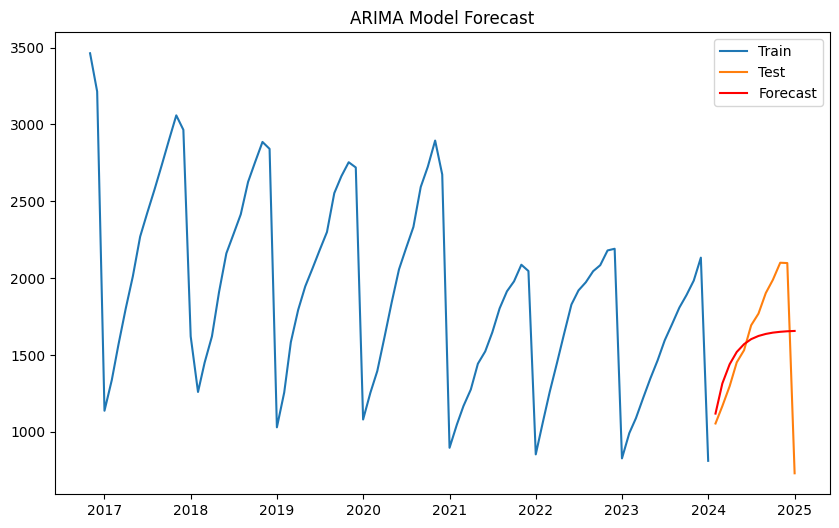

Mean Squared Error: 127302.91


In [24]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


# Set index to Month
# df_agg.index = pd.to_datetime(df_agg.index).to_period('M')

# Divide the data into training and test data
train = df_agg['Total Crimes'][:-12]
test = df_agg['Total Crimes'][-12:]

# Building the ARIMA model
model_arima = ARIMA(train, order=(1, 1, 1))  # ARIMA(p, d, q) parameters
model_fit_arima = model_arima.fit()

# Forecasting
forecast = model_fit_arima.forecast(steps=12)
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.title("ARIMA Model Forecast")
plt.legend()
plt.show()

# MSE
mse = mean_squared_error(test, forecast)
print(f"Mean Squared Error: {mse:.2f}")


Что в целом можно сказать по графику?

Временной ряд явно сезонный (есть повторяющиеся колебания).
Модель ARIMA (1,1,1) плохо передает сезонность, так как прогноз (оранжевая линия) сглаженный.
Настоящие данные имеют более резкие спады и подъемы, а модель делает более мягкий прогноз.
Можно попробовать SARIMA (учитывает сезонность) или Prophet для более точного предсказания.

## Time Series Analysis with SARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\asanb\AppData\Local\Temp\ipykernel_19408\384774507.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1),


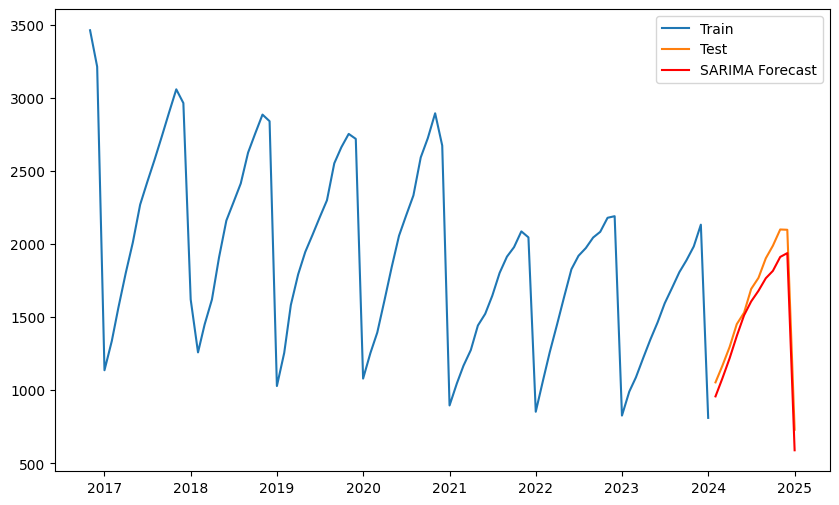

SARIMA Metrics:
MAE: 110.74
MSE: 14450.95
R2: 0.92

         Дата  SARIMA Forecast
0  2024-01-31       958.082321
1  2024-02-29      1080.736042
2  2024-03-31      1219.920264
3  2024-04-30      1370.711688
4  2024-05-31      1513.083165
5  2024-06-30      1607.721513
6  2024-07-31      1680.665822
7  2024-08-31      1766.455586
8  2024-09-30      1816.879387
9  2024-10-31      1912.148114
10 2024-11-30      1938.379817
11 2024-12-31       589.331929


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA: set period=12
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()
forecast_sarima = model_fit_sarima.forecast(steps=12)

# Create forecast df
df_sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1), 
                                                     periods=12, freq='M'),
                                'SARIMA Forecast': forecast_sarima.values})

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_sarima, label="SARIMA Forecast", color='red')
plt.legend()
plt.show()

# Metrics
mae = mean_absolute_error(test, forecast_sarima)
mse = mean_squared_error(test, forecast_sarima)
r2 = r2_score(test, forecast_sarima)

print(f"SARIMA Metrics:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR2: {r2:.2f}")
print(f"\n{df_sarima_forecast}")

### Forecasting corruption crimes numbers for the next two years with SARIMA

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\asanb\AppData\Local\Temp\ipykernel_19408\814012604.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]


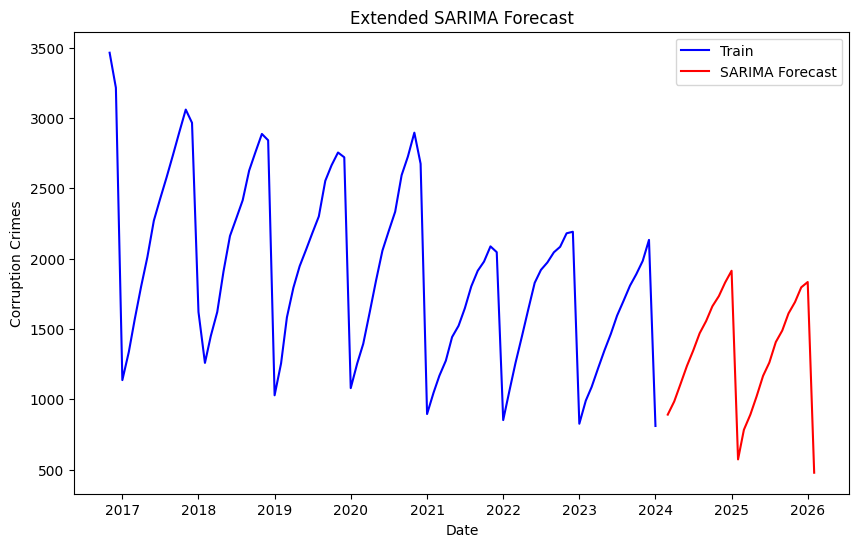

                 Date  SARIMA Forecast
2025-02-01 2024-02-29       891.593610
2025-03-01 2024-03-31       985.271913
2025-04-01 2024-04-30      1108.551810
2025-05-01 2024-05-31      1237.972298
2025-06-01 2024-06-30      1346.678524
2025-07-01 2024-07-31      1469.984311
2025-08-01 2024-08-31      1556.473238
2025-09-01 2024-09-30      1661.546837
2025-10-01 2024-10-31      1733.568416
2025-11-01 2024-11-30      1829.951580
2025-12-01 2024-12-31      1913.843331
2026-01-01 2025-01-31       573.517742
2026-02-01 2025-02-28       783.833745
2026-03-01 2025-03-31       891.636289
2026-04-01 2025-04-30      1021.456375
2026-05-01 2025-05-31      1167.039338
2026-06-01 2025-06-30      1261.470603
2026-07-01 2025-07-31      1407.194556
2026-08-01 2025-08-31      1489.147527
2026-09-01 2025-09-30      1610.809275
2026-10-01 2025-10-31      1691.129607
2026-11-01 2025-11-30      1796.008153
2026-12-01 2025-12-31      1833.805564
2027-01-01 2026-01-31       478.842831


In [26]:
# Fit the SARIMA model
model_sarima = SARIMAX(df_agg['Total Crimes'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

# Generate forecasts for the entire range, including 2025
forecast_steps = 24  # Adjust this to include 2025 (e.g., 24 months = 2 years from the end of training data)
sarima_forecast = model_fit_sarima.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]
sarima_forecast_values = sarima_forecast.predicted_mean

# Create a DataFrame for the SARIMA forecast
sarima_forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'SARIMA Forecast': sarima_forecast_values
})

# Plot the extended forecast
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train", color="blue")
plt.plot(sarima_forecast_df['Date'], sarima_forecast_df['SARIMA Forecast'], label="SARIMA Forecast", color="red")
plt.title("Extended SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes")
plt.legend()
plt.show()

# Print the extended SARIMA forecast
print(sarima_forecast_df)

## Time Series Analysis with Prophet

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
13:54:01 - cmdstanpy - INFO - Chain [1] start processing
13:54:02 - cmdstanpy - INFO - Chain [1] done processing


            ds         yhat
111 2026-01-31   823.154192
112 2026-02-28   552.358453
113 2026-03-31   788.175999
114 2026-04-30  1022.873586
115 2026-05-31  1277.057334
116 2026-06-30  1447.894897
117 2026-07-31  1595.410836
118 2026-08-31  1767.515382
119 2026-09-30  1806.652371
120 2026-10-31  1635.122934
121 2026-11-30  1839.983854
122 2026-12-31   503.232846


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


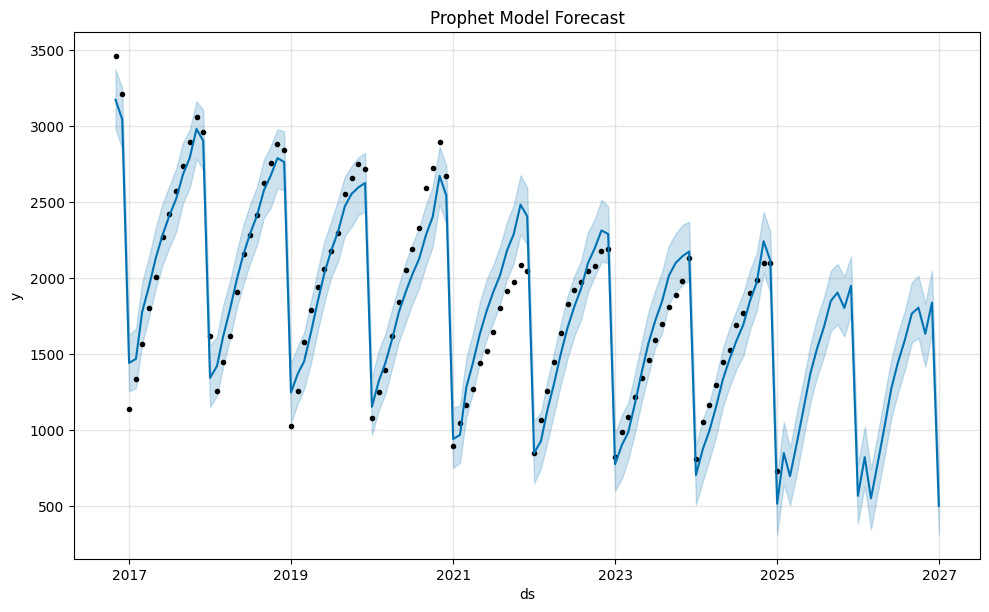

Prophet Metrics:
MAE: 107.55
MSE: 15350.48
R2: 0.91


In [27]:
from prophet import Prophet

# Preparing data for Prophet
prophet_df = df_agg.reset_index()[['Date', 'Total Crimes']]
prophet_df.columns = ['ds', 'y']  # Prophet's requirements

# Prophet model fit
model_prophet = Prophet()
model_prophet.fit(prophet_df)

# Forecast
future = model_prophet.make_future_dataframe(periods=24, freq='M')
forecast = model_prophet.predict(future)

# Prophet прогноз на 12 месяцев вперёд
prophet_forecast = forecast[['ds', 'yhat']].iloc[-12:]
print(prophet_forecast)

# Plot
fig = model_prophet.plot(forecast)
plt.title("Prophet Model Forecast")
plt.show()

# Extracting the real test values (last 12 months)
test = prophet_df.iloc[-12:]
test = test.set_index('ds')

# Extracting the predicted values for the test period
forecast_test = forecast[['ds', 'yhat']].set_index('ds').loc[test.index]

# Metrics
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
mse = mean_squared_error(test['y'], forecast_test['yhat'])
r2 = r2_score(test['y'], forecast_test['yhat'])

# Results
print(f"Prophet Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")



## Cross-validation for Prophet

In [28]:
from prophet.diagnostics import cross_validation, performance_metrics

# **Cross-Validation в Prophet**
df_cv = cross_validation(
    model_prophet,
    initial="1825 days",  # ~60 months
    period="365 days",    # ~12 months step
    horizon="365 days"    # Forecast horizon ~12 months
)

# Perfomance test
df_performance = performance_metrics(df_cv)
print(df_performance[["horizon", "mse", "rmse", "mae", "mape"]])

  0%|          | 0/3 [00:00<?, ?it/s]13:54:02 - cmdstanpy - INFO - Chain [1] start processing
13:54:02 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 1/3 [00:00<00:00,  2.75it/s]13:54:02 - cmdstanpy - INFO - Chain [1] start processing
13:54:03 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 2/3 [00:00<00:00,  2.65it/s]13:54:03 - cmdstanpy - INFO - Chain [1] start processing
13:54:03 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 3/3 [00:01<00:00,  2.85it/s]

    horizon            mse        rmse         mae      mape
0   30 days  172636.696292  415.495724  392.713593  0.374837
1   58 days  175595.391954  419.041039  378.697763  0.329020
2   59 days  150849.746816  388.393804  352.355686  0.293674
3   89 days  157884.801698  397.347205  345.458670  0.261111
4   90 days  147302.900995  383.800601  326.954374  0.237863
5  119 days  145539.514264  381.496414  302.237078  0.200171
6  120 days  139325.711398  373.263595  289.218217  0.184122
7  150 days  151820.672701  389.641724  295.691018  0.173475
8  151 days  141687.274991  376.413702  266.889032  0.152067
9  180 days  131805.004585  363.049590  263.540632  0.144703
10 181 days  140545.970287  374.894612  289.092968  0.157031
11 211 days  114987.704149  339.098369  275.050462  0.147204
12 212 days  110900.946946  333.017938  264.492078  0.139464
13 242 days   78843.695130  280.791195  254.972651  0.132748
14 243 days   75872.999692  275.450539  245.922168  0.125634
15 272 days   61625.4376

Анализ Cross-Validation для Prophet
1. Общая тенденция
MSE (Mean Squared Error) и RMSE (Root Mean Squared Error) уменьшаются с увеличением горизонта предсказания до ~300 дней.
После 303–304 дней ошибка начинает увеличиваться.
2. Оптимальный горизонт предсказания
Наименьший MSE: 48,300 при 304 днях
Наименьший RMSE: 219.77 при 304 днях
Наименьший MAE: 184.16 при 304 днях
Наименьший MAPE: 8.66% при 304 днях
Это говорит о том, что оптимальный горизонт предсказания для Prophet в этом случае — около 300 дней (10 месяцев).

3. Рост ошибки после 304 дней
После 304 дней MSE и RMSE резко увеличиваются.
В 364–365 дней (почти 1 год) ошибка значительно выше (MSE = 240,123).
Это указывает на то, что прогноз на год вперед сильно теряет точность.
Вывод
- 📌 Оптимальный горизонт предсказания: ~10 месяцев (304 дня)
- 📌 Прогноз на 12 месяцев (365 дней) сильно ухудшается
- 📌 Короткие прогнозы (30–150 дней) тоже показывают высокие ошибки

Прореформулируй под диссертацию:
"Based on cross-validation results, the optimal forecast horizon for Prophet is approximately 300 days. Beyond this point, the prediction error increases significantly, indicating reduced model reliability for long-term forecasts beyond 10 months."

### Cross-validation attempt [test]

Когда кросс-валидация полезна в временных рядах?
- Проверка устойчивости модели — помогает понять, насколько модель устойчива при прогнозировании на разных временных отрезках.
- Выявление переобучения — если модель хорошо работает на одной выборке, но плохо на другой, значит, она может подстраиваться под шум, а не выявлять реальные закономерности.
- Оптимизация гиперпараметров — можно использовать Time Series CV для подбора параметров SARIMA или Prophet.

Какие методы кросс-валидации подходят для временных рядов?
Обычный k-fold не подходит, так как он перемешивает данные. 
Вместо него можно использовать:

1. Rolling Window Cross-Validation (скользящее окно)
- Берём окно длиной N месяцев, обучаемся на нём, предсказываем следующий шаг.
- Сдвигаем окно на 1 шаг и повторяем.
- Например, если N = 36, модель обучается на 3 годах данных, потом предсказывает следующий месяц.

2. Expanding Window Cross-Validation (расширяющееся окно)
- Начинаем с небольшого периода (например, 24 месяца).
- Постепенно добавляем новые месяцы в обучающий набор.
- Проверяем, улучшается ли модель с добавлением данных.

## Cross-validation for SARIMA

#### Rolling Window Cross-Validation

In [29]:
def rolling_cv_sarima(data, order, seasonal_order, window_size=60, horizon=12):
    errors = []
    
    for start in range(len(data) - window_size - horizon):
        train = data[start : start + window_size]
        test = data[start + window_size : start + window_size + horizon]
        
        # fit model
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)
        
        # forecast
        forecast = model_fit.forecast(steps=horizon)
        
        # Metrics
        error = mean_squared_error(test, forecast)
        errors.append(error)
    
    return np.mean(errors), np.std(errors)

mean_mse, std_mse = rolling_cv_sarima(df_agg_new['Total Crimes'], order=(1,1,1), seasonal_order=(1,1,1,12))
print(f"Mean MSE: {mean_mse:.2f}, Std: {std_mse:.2f}")

NameError: name 'df_agg_new' is not defined

#### Expanding window cross-validation

In [ ]:
initial_train_size = 36  # Начальный размер обучающего окна
test_size = 12  # Размер тестового окна
y = df_agg["Total Crimes"]
mse_scores = []

for train_end in range(initial_train_size, len(y) - test_size + 1):
    train_data = y.iloc[:train_end]  # Обучающая выборка расширяется на каждом шаге
    test_data = y.iloc[train_end:train_end + test_size]  # Тестовая выборка фиксированного размера
    
    # Обучаем модель на train_data
    model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit = model.fit(disp=False)
    
    # Делаем предсказание
    predictions = model_fit.forecast(steps=test_size)
    
    # Оцениваем MSE
    mse = mean_squared_error(test_data, predictions)
    mse_scores.append(mse)

# Вычисляем средний и стандартное отклонение ошибки
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)

print(f"Expanding Window CV - Mean MSE: {mean_mse:.2f}, Std: {std_mse:.2f}")

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood op

Expanding Window CV - Mean MSE: 60817.13, Std: 51987.95


Сравним результаты по каждой метрике:

MAE (Mean Absolute Error)

Gradient Boosting: 105.84

SARIMA: 110.74

Интерпретация: В среднем по модулю градиентный бустинг ошибается на 105.84, а SARIMA — на 110.74. Значит, GBT чуть лучше в среднем приближается к фактическим значениям.

MSE (Mean Squared Error)

Gradient Boosting: 24,436.40

SARIMA: 14,450.95

Интерпретация: По MSE у SARIMA результат лучше (14.4k против 24.4k). MSE сильнее «штрафует» за крупные отклонения (квадрат ошибки), поэтому более высокое значение у GBT может означать, что у него есть отдельные выбросы (большие ошибки).

𝑅
2
 

Gradient Boosting: 0.94

SARIMA: 0.92

Интерпретация: GBT объясняет чуть больше дисперсии (94%) против 92% у SARIMA. Разница невелика, но формально GBT показывает чуть лучшее приближение в терминах доли объяснённой вариации.

Почему могут возникать противоречия?
MAE и R² лучше у GBT, но MSE лучше у SARIMA.

Это может говорить о том, что GBT в целом даёт более точный прогноз (по MAE и R²), но в отдельных случаях делает более крупные ошибки (из-за чего MSE возрастает).

SARIMA, наоборот, может давать чуть большие ошибки «в среднем», но не допускает таких больших «провалов», что приводит к более низкому MSE.

Какую модель выбрать?
Если вам важны средние ошибки (MAE) и общий уровень объяснённой вариации (R²), то GBT выглядит лучше.

Если важнее избегать крупных промахов (большая чувствительность к выбросам), то SARIMA предпочтительнее (из-за меньшего MSE).

Стоит также взглянуть на график остатков и распределение ошибок (или посмотреть RMSE), чтобы понять, насколько часто и насколько сильно GBT «промахивается» в сравнении с SARIMA.

В итоге выбор модели зависит от целей анализа и того, что важнее — минимизация средних ошибок (MAE) или стабильность и контроль крупных отклонений (MSE).

# SARIMA и Prophet в stacked hybrid

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
11:31:23 - cmdstanpy - INFO - Chain [1] start processing
11:31:23 - cmdstanpy - INFO - Chain [1] done processing


Stacked Hybrid Model Metrics:
MAE: 25.67
MSE: 1123.24
R2: 0.99


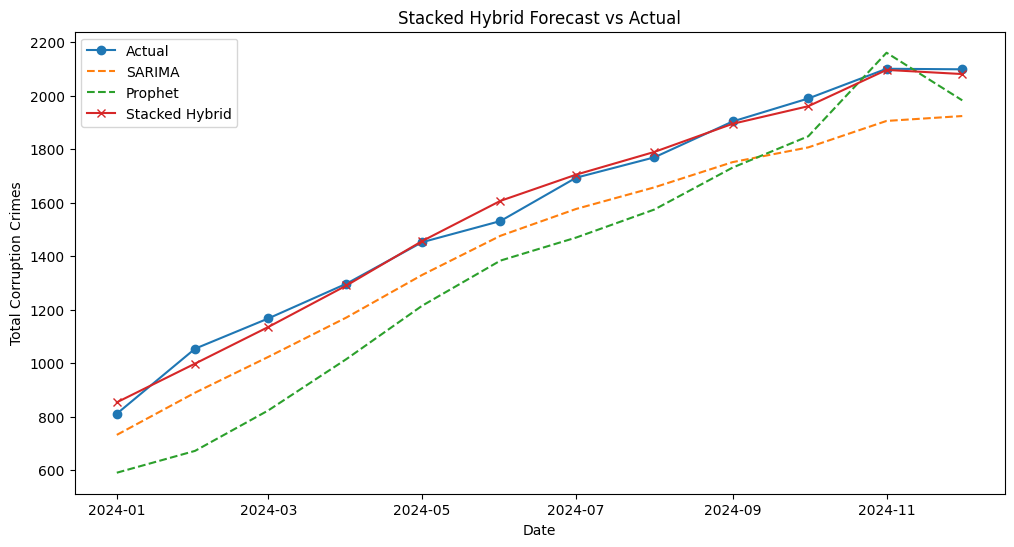

In [ ]:
# Предположим, что у нас есть DataFrame df_sh с колонками 'Date' и 'Total Crimes'
# Преобразуем дату и отсортируем данные
df_sh = df_agg[["Total Crimes"]].copy()

# Разделим данные:
# Допустим, тренировка – до конца 2023, тест – 2024 (12 месяцев)
train = df_sh.loc[:'2023-12-31']['Total Crimes']
test = df_sh.loc['2024-01-01':'2024-12-31']['Total Crimes']

### 1. Обучение SARIMA и прогноз на тестовый период

model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit(disp=False)
sarima_forecast = model_fit_sarima.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean

### 2. Обучение Prophet и прогноз на тестовый период

# Подготавливаем данные для Prophet (требуется DataFrame с колонками ds и y)
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']
model_prophet = Prophet()
model_prophet.fit(prophet_train)

# Создаем будущее на длину тестового периода (используем, например, 'MS' для начала месяца, если тест имеет даты начала месяца)
future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
forecast_prophet = model_prophet.predict(future)

# Устанавливаем индекс 'ds' и переиндексируем по тестовому индексу, используя ближайшие значения
prophet_pred = forecast_prophet.set_index('ds')['yhat']
prophet_pred = prophet_pred.reindex(test.index, method='nearest')

### 3. Объединение прогнозов базовых моделей

df_stack = pd.DataFrame({
    'Actual': test,
    'SARIMA': sarima_pred,
    'Prophet': prophet_pred
})

### 4. Обучение мета-модели (stacking) на прогнозах базовых моделей

# Используем прогнозы SARIMA и Prophet как признаки
X_stack = df_stack[['SARIMA', 'Prophet']].values
y_stack = df_stack['Actual'].values

meta_model = LinearRegression()
meta_model.fit(X_stack, y_stack)
stacked_pred = meta_model.predict(X_stack)

### 5. Вычисление метрик и визуализация

mae = mean_absolute_error(y_stack, stacked_pred)
mse = mean_squared_error(y_stack, stacked_pred)
r2 = r2_score(y_stack, stacked_pred)

print("Stacked Hybrid Model Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

# Создаем DataFrame с итоговыми прогнозами
df_stack['Stacked'] = stacked_pred

# Построим график: фактические значения vs. прогнозы базовых моделей и итоговый стек
plt.figure(figsize=(12, 6))
plt.plot(df_stack.index, df_stack['Actual'], label='Actual', marker='o')
plt.plot(df_stack.index, df_stack['SARIMA'], label='SARIMA', linestyle='--')
plt.plot(df_stack.index, df_stack['Prophet'], label='Prophet', linestyle='--')
plt.plot(df_stack.index, df_stack['Stacked'], label='Stacked Hybrid', linestyle='-', marker='x')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Stacked Hybrid Forecast vs Actual')
plt.legend()
plt.show()


Судя по графику и метрикам:

Высокий 𝑅 2 (0.99)
Это говорит о том, что объединённая (stacked) модель очень хорошо объясняет вариацию данных в тестовом периоде. Значение 0.99 означает, что около 99% разброса фактических значений учтено моделью.

Низкий MAE (25.67)
Средняя абсолютная ошибка около 25.67 значит, что в среднем на всём тестовом промежутке прогноз отклоняется от фактических значений примерно на 26 единиц. С учётом того, что уровень преступлений превышает 1000-2000 в ряде точек, такая ошибка относительно невелика.

MSE (1123.24)
Среднеквадратичная ошибка чуть выше тысячи. Поскольку MSE сильнее «штрафует» крупные промахи, чем MAE, это значение говорит, что крупных «выбросов» в ошибках немного, но они могут чуть повышать MSE.

Визуальный анализ графика

Stacked Hybrid (красная линия) идёт очень близко к фактическим точкам (синим), особенно ближе к концу ряда.

SARIMA (оранжевая) и Prophet (зелёная) в данном случае дают прогнозы, которые заметно ниже фактических в конце периода, но модель SARIMA ближе к данным в начале периода.

Благодаря мета-модели (линейная регрессия в стэкинге), итоговый прогноз (Stacked) корректируется и идёт близко к фактическим значениям.

Итог
Stacked Hybrid сумел объединить преимущества SARIMA и Prophet, дав точный итоговый прогноз.

Низкие ошибки и высокий R2 подтверждают, что данный подход хорошо подходит для данных тестового периода.

Если нужно долгосрочное прогнозирование (выходящее за пределы тестовых дат), всё равно стоит следить за тем, чтобы в данных не происходило резких изменений, которые ни SARIMA, ни Prophet не видели.

В целом, эти результаты указывают, что гибридная модель, комбинирующая тренд и сезонность (SARIMA, Prophet), способна достичь высокой точности на имеющемся тестовом отрезке.

## CV for stacked hybrid

In [ ]:
# Параметры кросс-валидации
test_horizon = 12  # Сколько месяцев в тестовом отрезке
n_folds = 3        # Сколько "складок" (folds) сделаем

# Вычислим, сколько данных всего
n_total = len(df_sh)

# Подготовим списки для метрик
mae_list, mse_list, r2_list = [], [], []

dates = df_sh.index

# Функция для обучения базовых моделей и построения stacked hybrid
def train_stacked_model(train_data, test_data):
    """Возвращает предсказания stacked-модели на тесте и фактические значения."""
    # 1) SARIMA
    model_sarima = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    model_fit_sarima = model_sarima.fit(disp=False)
    sarima_forecast = model_fit_sarima.get_forecast(steps=len(test_data))
    sarima_pred = sarima_forecast.predicted_mean

    # 2) Prophet
    prophet_train = train_data.reset_index()
    prophet_train.columns = ['ds', 'y']
    model_prophet = Prophet()
    model_prophet.fit(prophet_train)
    
    future = model_prophet.make_future_dataframe(periods=len(test_data), freq='MS')
    forecast_prophet = model_prophet.predict(future)
    
    # Переиндексируем по датам test_data
    prophet_pred = forecast_prophet.set_index('ds')['yhat']
    # Если индексы теста – первое число месяца, а Prophet выдаёт конец месяца,
    # можно reindex(..., method='nearest'), чтобы сопоставить даты
    prophet_pred = prophet_pred.reindex(test_data.index, method='nearest')

    # 3) Обучение stacked-модели
    df_stack = pd.DataFrame({
        'Actual': test_data,
        'SARIMA': sarima_pred,
        'Prophet': prophet_pred
    })

    X_stack = df_stack[['SARIMA', 'Prophet']].values
    y_stack = df_stack['Actual'].values
    
    meta_model = LinearRegression()
    meta_model.fit(X_stack, y_stack)
    stacked_pred = meta_model.predict(X_stack)

    return y_stack, stacked_pred  # Возвращаем фактические значения и прогноз стэка

# Главный цикл кросс-валидации
# Определим начальный размер train, затем будем расширять
# Например, разобьём оставшиеся данные на n_folds отрезков для теста
# Пример: если у нас много данных, можно делать более гибкую логику
start_train_size = len(df_sh) - (n_folds * test_horizon)
# В реальности стоит убедиться, что start_train_size > 0

for fold in range(n_folds):
    # Конец train = start_train_size + fold * test_horizon
    end_train_idx = start_train_size + fold * test_horizon
    
    # Тренировочный отрезок
    train_data = df_sh.iloc[:end_train_idx]['Total Crimes']
    
    # Тестовый отрезок
    test_data = df_sh.iloc[end_train_idx : end_train_idx + test_horizon]['Total Crimes']
    
    if len(test_data) < test_horizon:
        # Если данных не хватает, выходим
        break
    
    # Обучаем stacked-модель на train_data, получаем прогноз на test_data
    y_true, y_pred = train_stacked_model(train_data, test_data)
    
    # Считаем метрики
    mae_fold = mean_absolute_error(y_true, y_pred)
    mse_fold = mean_squared_error(y_true, y_pred)
    r2_fold = r2_score(y_true, y_pred)
    
    mae_list.append(mae_fold)
    mse_list.append(mse_fold)
    r2_list.append(r2_fold)
    
    # print(f"Fold {fold+1}:")
    # print(f"  MAE: {mae_fold:.2f}")
    # print(f"  MSE: {mse_fold:.2f}")
    # print(f"  R2 : {r2_fold:.2f}\n")

# После цикла усредняем метрики
mean_mae = np.mean(mae_list)
mean_mse = np.mean(mse_list)
mean_r2  = np.mean(r2_list)

print("=== Cross-Validation Results ===")
print(f"Average MAE: {mean_mae:.2f}")
print(f"Average MSE: {mean_mse:.2f}")
print(f"Average R2 : {mean_r2:.2f}")

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
11:39:38 - cmdstanpy - INFO - Chain [1] start processing
11:39:39 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infer

=== Cross-Validation Results ===
Average MAE: 38.11
Average MSE: 2648.61
Average R2 : 0.99


Такие высокие метрики, как R 2 равный 0.99, действительно могут вызвать подозрения на переобучение, особенно если модель слишком точно «подогнана» под обучающие данные. Однако важно учитывать следующее:

Кросс-валидация:
Если вы проводите кросс-валидацию, особенно с временными рядами (например, с расширяющимся окном), и метрики остаются стабильными на разных подвыборках, это говорит о том, что модель демонстрирует высокую устойчивость и переобучение не является критической проблемой.

Характер данных:
Возможно, временной ряд действительно имеет сильные, хорошо предсказуемые закономерности (например, выраженную сезонность и тренд), что позволяет модели достичь очень высоких результатов.

Сложность модели:
В данном случае мета-модель — линейная регрессия, которая сама по себе не склонна к переобучению, особенно если количество базовых моделей невелико (здесь две: SARIMA и Prophet). Однако, если базовые модели переобучены, итоговый стек может «унаследовать» эту проблему.

Проверка на новых данных:
Лучший способ убедиться, что переобучение не является проблемой — протестировать модель на полностью новых данных, которые не использовались ни для обучения, ни для кросс-валидации.

Таким образом, хотя высокие результаты могут быть вызваны переобучением, если кросс-валидация проводилась корректно и модель показывает стабильные метрики на разных подвыборках, это скорее свидетельствует о хорошем качестве модели, чем о переобучении. Тем не менее, стоит дополнительно проверить модель на независимых данных или использовать дополнительные методы оценки (например, анализ остатков, тесты на стационарность ошибок) для окончательного заключения.

## Analysis of Residuals in stacked hybrid

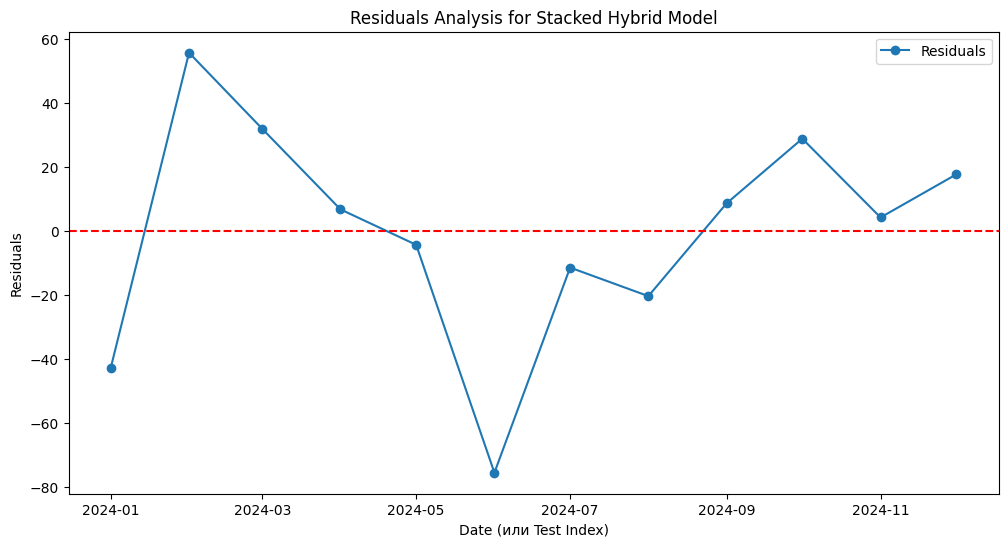

In [ ]:
# Предположим, что у вас уже есть DataFrame df_stack с колонками 'Actual' и 'Stacked'
# Вычисляем остатки
df_stack['Residuals'] = df_stack['Actual'] - df_stack['Stacked']

# Построим график остатков по времени (или по индексам, если это последовательность тестовых наблюдений)
plt.figure(figsize=(12, 6))
plt.plot(df_stack.index, df_stack['Residuals'], marker='o', linestyle='-', label='Residuals')
plt.axhline(0, color='red', linestyle='--')  # Линия y=0
plt.xlabel('Date (или Test Index)')
plt.ylabel('Residuals')
plt.title('Residuals Analysis for Stacked Hybrid Model')
plt.legend()
plt.show()

## Forecast numbers of 25/26 years

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
16:02:09 - cmdstanpy - INFO - Chain [1] start processing
16:02:10 - cmdstanpy - INFO - Chain [1] done processing


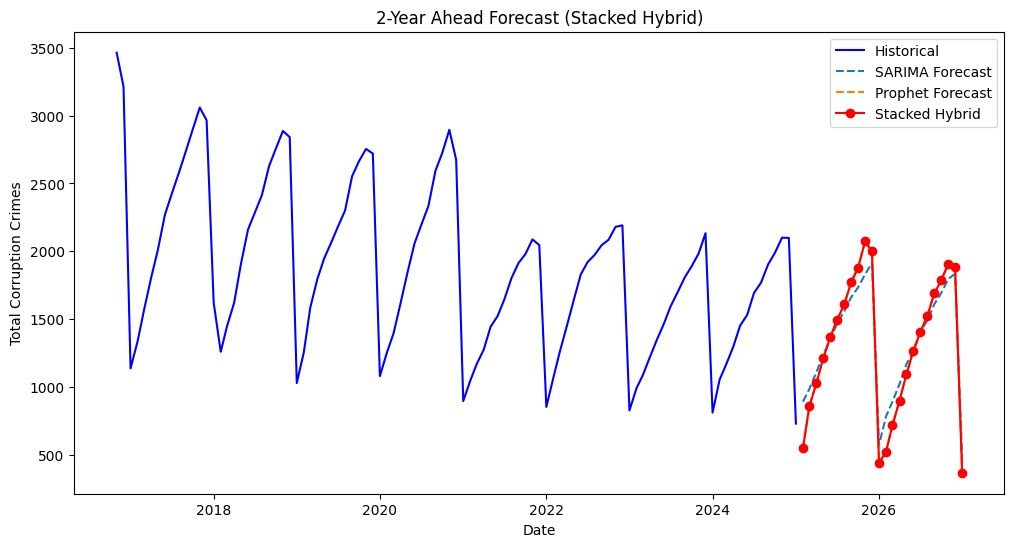

In [ ]:
y = df_sh['Total Crimes']

# Обучим SARIMA и Prophet на всех исторических данных (до последней даты в df_sh)
train_data = y.copy()

### 2) Обучение SARIMA на всём датасете
sarima_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)

### 3) Обучение Prophet на всём датасете
prophet_train = train_data.reset_index()
prophet_train.columns = ['ds', 'y']
model_prophet = Prophet()
model_prophet.fit(prophet_train)

# 4) Получение "исторических" прогнозов для обучения мета-модели
#    Мы хотим, чтобы и SARIMA, и Prophet выдавали прогноз на те даты, которые уже есть в train_data,
#    чтобы потом сравнить с фактическими значениями и обучить линейную регрессию.

# SARIMA in-sample predictions
sarima_in_sample = sarima_fit.fittedvalues  # или model_fit.get_prediction(start=..., end=...)

# Prophet in-sample predictions
# Для Prophet сделаем predict на весь исторический период (train_data)
future_train = model_prophet.make_future_dataframe(periods=0, freq='MS') 
# Указываем частоту 'MS', если данные помесячные (Month Start)
# (Если у вас daily, тогда freq='D', и т.д.)

prophet_pred_full = model_prophet.predict(future_train)
prophet_pred_full = prophet_pred_full.set_index('ds')['yhat']

# Теперь нам нужно совместить SARIMA in-sample и Prophet in-sample на совпадающих датах
df_in_sample = pd.DataFrame({
    'Actual': train_data,  # фактические значения
    'SARIMA': sarima_in_sample,
    'Prophet': prophet_pred_full
})

# Удалим строки, где есть NaN (в начале ряда SARIMA может быть NaN)
df_in_sample.dropna(inplace=True)

# 5) Обучение мета-модели (LinearRegression)
X_stack = df_in_sample[['SARIMA', 'Prophet']]
y_stack = df_in_sample['Actual']

meta_model = LinearRegression()
meta_model.fit(X_stack, y_stack)

# 6) Прогноз на 2 года вперёд (24 месяца)
# Определим последнюю дату в исторических данных
last_date = df_sh.index[-1]
# Сформируем даты будущего периода (24 месяца вперёд)
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=24,
    freq='MS'
)

### 6a) Прогноз SARIMA на 24 месяца вперёд
sarima_forecast = sarima_fit.get_forecast(steps=24)
sarima_future_pred = sarima_forecast.predicted_mean
sarima_future_pred.index = future_dates  # переименуем индекс под наши будущие даты

### 6b) Прогноз Prophet на 24 месяца вперёд
future_df = model_prophet.make_future_dataframe(periods=24, freq='MS')
prophet_forecast = model_prophet.predict(future_df)
prophet_forecast = prophet_forecast.set_index('ds')['yhat'].iloc[-24:]  # последние 24 строки
prophet_forecast.index = future_dates  # переименуем индекс

### 6c) Формируем DataFrame с базовыми прогнозами
df_future = pd.DataFrame({
    'SARIMA': sarima_future_pred,
    'Prophet': prophet_forecast
}, index=future_dates)

# 7) Применяем мета-модель к будущим прогнозам
X_future = df_future[['SARIMA', 'Prophet']]
stacked_pred = meta_model.predict(X_future)

df_future['Stacked'] = stacked_pred

# 8) Визуализация итогового прогноза
plt.figure(figsize=(12, 6))

# Построим исторические данные
plt.plot(y.index, y.values, label='Historical', color='blue')

# Построим будущие прогнозы
plt.plot(df_future.index, df_future['SARIMA'], '--', label='SARIMA Forecast')
plt.plot(df_future.index, df_future['Prophet'], '--', label='Prophet Forecast')
plt.plot(df_future.index, df_future['Stacked'], '-o', label='Stacked Hybrid', color='red')

plt.title('2-Year Ahead Forecast (Stacked Hybrid)')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.legend()
plt.show()

In [ ]:
df_future

,SARIMA,Prophet,Stacked
2025-02-01,891.593610,545.626049,549.296274
2025-03-01,985.271913,856.967547,857.574041
2025-04-01,1108.551810,1027.448570,1027.590475
2025-05-01,1237.972298,1212.699275,1212.259841
2025-06-01,1346.678524,1368.047610,1367.123644
2025-07-01,1469.984311,1495.030136,1494.290609
2025-08-01,1556.473238,1608.850464,1607.871230
2025-09-01,1661.546837,1772.704361,1771.052558
2025-10-01,1733.568416,1881.010923,1878.957836
2025-11-01,1829.951580,2075.519690,2072.190506


----------------------------------

Заметка для заключение: Будущие исследования могут включать построение нейронной сети, которая сможет «видеть» закономерность и продолжать её

Значит, если наша цель, построить модель, которая сможет прогнозировать кол-во преступлений, нам мало будет просто XGBoost Regressor

Да, именно так. Если ваша задача — прогнозировать количество преступлений, особенно если ожидается, что ряд будет продолжать тренд или выходить за пределы диапазона обучающих данных, то простого XGBoost Regressor может оказаться недостаточно.

Значит нам нужно найти признаки, которые помогут временным моделям предсказывать целевую переменную?

Да, совершенно верно. Эффективное прогнозирование временных рядов сильно зависит от правильной инженерии признаков. 

Нужно найти или создать такие признаки, которые:

Отражают временную динамику:
Например, порядковый номер времени (time dummy), временные метки, которые позволяют модели «видеть» тренд и сезонность.

Улавливают сезонность:
Это могут быть сезонные индикаторы (one-hot encoding месяцев, дней недели) или Fourier-признаки, которые компактно описывают повторяющиеся волновые паттерны.

Отражают автокорреляцию:
Лаговые признаки (значения целевой переменной из предыдущих периодов) позволяют моделям учитывать зависимость от прошлых наблюдений.

Включают внешние (экзогенные) переменные:
Если есть дополнительные данные (например, новости, экономические показатели), которые могут влиять на уровень преступлений, их также стоит включить.

Таким образом, для временных моделей, таких как SARIMA или Prophet, очень важно правильно выделить признаки, отражающие временные закономерности, чтобы улучшить точность прогнозов.

## Также для будущих исследований сделать многовыходное или мультишаговое прогнозирование (одно и тоже, два названия)

Стоит ли нам это делать, если у нас итак хорошие показатели? r2 mae mse

Да, метрики (R², MAE, MSE) указывают на то, что модель уже хорошо работает. Однако выбор подхода зависит не только от текущей точности, но и от практических требований:

Прогноз на несколько шагов вперёд:
Если ваша задача требует одновременного предсказания будущих значений на несколько периодов (например, прогноз на 3 или 12 месяцев вперёд), то прямое обучение модели на многовыходной задаче позволяет получить согласованные прогнозы и избежать накопления ошибок, характерного для рекурсивного (одноступенчатого) прогнозирования.

Согласованность прогнозов:
Даже при хороших метриках, если вы делаете прогноз по одному шагу, а затем последовательно используете его для получения следующих шагов, ошибки могут накапливаться. Многовыходной подход обучает модель выдавать весь горизонт сразу, что может быть полезно для стабильности долгосрочного прогнозирования.

Применимость к конкретной задаче:
Если в вашей задаче важно, чтобы прогнозы на несколько периодов были логически связаны и согласованы, то стоит рассмотреть многовыходной прогноз. Если же достаточно одноступенчатых прогнозов, и у вас нет необходимости предсказывать сразу несколько шагов, то можно оставить текущий подход.

Таким образом, даже если метрики хорошие, если ваша практическая задача требует прогнозирования на несколько шагов вперед, применение многовыходного (multitarget) прогнозирования может оказаться полезным. Это не столько про улучшение метрик, сколько про обеспечение согласованности и надежности долгосрочных прогнозов.